In [1]:
import json
import pandas as pd
import numpy as np
from haversine import haversine
import itertools
import re
import networkx as nx
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point, LineString
from matplotlib.colors import ListedColormap

search_type_mapping = {"Pharmacy": 0, "Grocery": 1}
stay_time_mapping = {0: 30, 1: 60}
average_speed = 0.5 # km/min
distance_factor = 1.5

current_day = "Monday"
departure_time = 10

[0, 25, 35, 158]


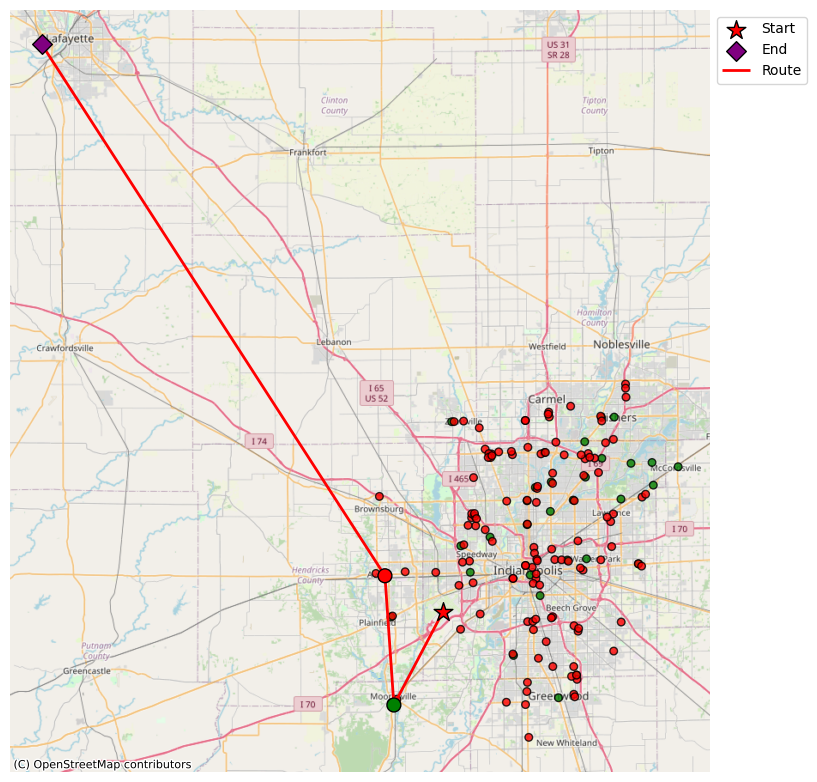

In [2]:
def find_closest_airport(name, airports_df):
    return airports_df['name'].iloc[
        airports_df['name'].str.lower().map(
            lambda x: len(set(x.split()) & set(name.lower().split()))
        ).argmax()
    ]

def find_mission_location(mission):
    data = []
    with open('indiana_yelp.json', 'r') as file:
        for line in file:
            record = json.loads(line)
            if record['categories'] and mission in record['categories']:
                if record['hours'] and current_day in record['hours'] and record['hours'][current_day] != '0:0-0:0' and record['hours'][current_day] != '':
                    data.append({
                        'name': record['name'],
                        'latitude': record['latitude'],
                        'longitude': record['longitude'],
                        'stars': record['stars'],
                        'review_count': record['review_count'],
                        'hours': record['hours'][current_day],
                        'mission': mission,
                        'group': search_type_mapping[mission]
                    })
    return data

def build_combined_graph(all_mission_data, start_airport, end_airport):
    mission_coords = [(loc['latitude'], loc['longitude']) for loc in all_mission_data]
    all_coords = [(start_airport['latitude'], start_airport['longitude'])] + mission_coords + [(end_airport['latitude'], end_airport['longitude'])]
    positions = {i: (coords[1], coords[0]) for i, coords in enumerate(all_coords)}
    
    edge_indices = []
    edge_weights = []
    
    for i in range(len(all_coords)):
        for j in range(len(all_coords)):
            if i != j:
                edge_indices.append([i, j])
                edge_weights.append(haversine(all_coords[i], all_coords[j]))
    
    graph = {
        'positions': positions,
        'edge_indices': edge_indices,
        'edge_weights': edge_weights,
        'start_node': 0,
        'goal_node': len(all_coords) - 1,
        'groups': [-1] + [loc['group'] for loc in all_mission_data] + [-1],
        'ratings': [-1.0] + [loc['stars'] for loc in all_mission_data] + [-1.0],
        'num_ratings': [-1] + [loc['review_count'] for loc in all_mission_data] + [-1],
        'openings': [''] + [str(loc['hours']) for loc in all_mission_data] + [''],
    }
    
    return graph

def compute_path_and_cost(graph, selected_groups, node_in_groups):
    start_node = graph['start_node']
    goal_node = graph['goal_node']
    positions = graph['positions']
    groups = graph['groups']
    ratings = graph['ratings']
    num_ratings = graph['num_ratings']
    openings = graph['openings']
    alpha = 0.25
    beta = 0.5

    rating_range = (1, 5)
    travel_times = [haversine(positions[n1], positions[n2]) * distance_factor / average_speed / 60 for group in node_in_groups for n1 in group for n2 in group if n1 != n2]

    num_ratings_list = [num_ratings[node] for group in node_in_groups for node in group]
    travel_time_range = (min(travel_times), max(travel_times))
    num_ratings_range = (min(num_ratings_list), max(num_ratings_list))
    
    def min_max_normalize(value, value_range, zero_case=0.0):
        if value_range[0] == value_range[1]:
            return zero_case
        return (value - value_range[0]) / (value_range[1] - value_range[0])

    def calculate_real_time(node1, node2):
        travel_time = haversine(positions[node1], positions[node2]) * distance_factor / average_speed / 60
        stay_time = stay_time_mapping[groups[node2]] / 60 if groups[node2] != -1 else 0
        return travel_time + stay_time

    def calculate_weight(node1, node2):
        travel_time = min_max_normalize(haversine(positions[node1], positions[node2]) * distance_factor / average_speed / 60, travel_time_range, zero_case=0.0)
        if node2 == goal_node:
            return travel_time
        node_rating = min_max_normalize(ratings[node2], rating_range, zero_case=1.0)
        node_num_ratings = min_max_normalize(num_ratings[node2], num_ratings_range, zero_case=1.0)
        return - (alpha * node_rating + alpha * node_num_ratings) + beta * travel_time
    
    edges = [(start_node, node, calculate_weight(start_node, node)) 
            for node in node_in_groups[selected_groups[0]]]
    edges.extend([(prev_node, next_node, calculate_weight(prev_node, next_node))
                 for prev_group, next_group in zip(selected_groups[:-1], selected_groups[1:])
                 for prev_node in node_in_groups[prev_group]
                 for next_node in node_in_groups[next_group]])
    edges.extend([(node, goal_node, calculate_weight(node, goal_node)) 
                 for node in node_in_groups[selected_groups[-1]]])
    
    G = nx.DiGraph()
    G.add_weighted_edges_from(edges)
    _, path = nx.single_source_bellman_ford(G, source=start_node, target=goal_node, weight='weight')
    if not check_path_availability(path, groups, goal_node, positions, openings):
        return float('inf'), path

    real_time = departure_time + sum(calculate_real_time(path[i], path[i+1]) for i in range(len(path)-1))
    return real_time, path

def MSGS(graph):
    start_node = graph['start_node']
    goal_node = graph['goal_node']
    groups = graph['groups']
    node_in_groups = []

    group_indices = np.unique([group_id for group_id in groups if group_id >= 0]).tolist()
    for group_id in group_indices:
        node_indices = np.where(np.array(groups) == group_id)[0]
        node_in_group = [idx for idx in node_indices if idx not in [start_node, goal_node]]
        node_in_groups.append(node_in_group)
    group_indices = list(range(len(node_in_groups)))

    best_weight = float('inf')
    best_path = None
    for num_groups in range(len(group_indices), 0, -1):
        for groups_subset in itertools.combinations(group_indices, num_groups):
            for perm in itertools.permutations(groups_subset):
                w, p = compute_path_and_cost(graph, perm, node_in_groups)
                if w < best_weight:
                    best_weight = w
                    best_path = p
                    route = best_path
                    break
            if best_path is not None:
                break
        if best_path is not None:
            break     
    if best_path is None:
        route = [start_node, goal_node]

    return route

def parse_time(time_str):
    times = time_str.split('-')
    converted_times = []
    
    for time in times:
        hour, minute = time.split(':')
        converted_time = float(hour) + float(minute)/60
        converted_times.append(converted_time)
    
    return converted_times

def check_path_availability(path, groups, goal_node, positions, opening_hours, start_time=departure_time):
    current_time = start_time
    for i in range(len(path)-1):
        node1, node2 = path[i], path[i+1]
        travel_time = haversine(positions[node1], positions[node2]) * distance_factor / average_speed / 60
        current_time += travel_time
        if node2 != goal_node:
            day_opening_hours = opening_hours[node2]

            start_time, end_time = parse_time(day_opening_hours)
            if not (start_time <= current_time <= end_time):
                return False
            current_time += stay_time_mapping[groups[node2]] / 60 if groups[node2] != -1 else 0
    return True


def plot_routes(mission_data, route, start_idx, end_idx):
    fig, ax = plt.subplots(figsize=(8, 8))
    mission_colors = ['red', 'green', 'blue', 'purple', 'orange', 'yellow', 'brown', 'pink', 'cyan', 'magenta']

    mission_df = pd.DataFrame(mission_data)
    geometry = [Point(lon, lat) for lon, lat in zip(mission_df['longitude'], mission_df['latitude'])]
    mission_gdf = gpd.GeoDataFrame(mission_df, geometry=geometry, crs="EPSG:4326").to_crs(epsg=3857)
    unique_missions = mission_gdf['mission'].unique()
    mission_gdf.plot(ax=ax, column='mission', categorical=True, markersize=30, alpha=0.8, edgecolor='black', 
                    legend=True, legend_kwds={'title': 'Mission Type'}, cmap=ListedColormap(mission_colors[:len(unique_missions)]))
    
    airports_gdf = gpd.GeoDataFrame(airports_df, geometry=gpd.points_from_xy(airports_df['longitude'], airports_df['latitude']), crs="EPSG:4326").to_crs(epsg=3857)
    start_point = airports_gdf.iloc[[start_idx]]
    start_point.plot(ax=ax, color='red', marker='*', markersize=200, edgecolor='black', label='Start', zorder=2)
    end_point = airports_gdf.iloc[[end_idx]]
    end_point.plot(ax=ax, color='purple', marker='D', markersize=100, edgecolor='black', label='End', zorder=2)

    mission_idx = [x - 1 for x in route[1:-1]]
    mission_point = mission_gdf.iloc[mission_idx]
    mission_point.plot(ax=ax, column='mission', categorical=True, markersize=100, edgecolor='black',
                        cmap=ListedColormap(mission_colors[:len(unique_missions)]), zorder=2)
    route_coords = []
    route_coords.append(start_point.geometry.iloc[0])
    for idx in mission_idx:
        route_coords.append(mission_gdf.geometry.iloc[idx])
    route_coords.append(end_point.geometry.iloc[0])
    route_line = gpd.GeoSeries([LineString(route_coords)], crs=mission_gdf.crs)
    route_line.plot(ax=ax, color='red', linewidth=2, label='Route', zorder=1)

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def save_route_to_txt(mission_data, route, filename):
    ordered_points = []
    for idx in route:
        point = mission_data[idx]
        ordered_points.append([point['latitude'], point['longitude'], 0])
    points_array = np.array(ordered_points)
    np.savetxt(filename, points_array)

def main(start_name, end_name, missions):
    start = find_closest_airport(start_name, airports_df)
    end = find_closest_airport(end_name, airports_df)
    start_idx = airports_df[airports_df['name'] == start].index[0]
    end_idx = airports_df[airports_df['name'] == end].index[0]
    start_airport = airports_df.iloc[start_idx]
    end_airport = airports_df.iloc[end_idx]

    mission_data = []
    for mission in missions:
        mission_locations = find_mission_location(mission)
        mission_data.extend(mission_locations)
    
    graph = build_combined_graph(mission_data, start_airport, end_airport)
    route = MSGS(graph)
    print(route)
    plot_routes(mission_data, route, start_idx, end_idx)
    mission_data = [{'latitude': start_airport['latitude'], 'longitude':start_airport['longitude']}] + mission_data + [{'latitude': end_airport['latitude'], 'longitude':end_airport['longitude']}]
    return mission_data, route
    
filename = "use_case_2.txt"
airports_df = pd.read_csv('indiana_airports.csv')
airports_df = airports_df.dropna(subset=['ICAO_ID'])
mission_data, route = main(start_name="Indianapolis Intl", end_name="Purdue University", missions=["Pharmacy", "Grocery"])
save_route_to_txt(mission_data, route, filename=filename)

In [3]:
mission_data

[{'name': 'CVS Pharmacy',
  'latitude': 39.7371,
  'longitude': -86.1391,
  'stars': 2.5,
  'review_count': 10,
  'hours': '8:0-21:0',
  'mission': 'Pharmacy',
  'group': 0},
 {'name': 'CVS Pharmacy',
  'latitude': 39.9059375,
  'longitude': -86.0401804,
  'stars': 2.0,
  'review_count': 15,
  'hours': '7:0-0:0',
  'mission': 'Pharmacy',
  'group': 0},
 {'name': 'CVS Pharmacy',
  'latitude': 39.7107,
  'longitude': -86.3779,
  'stars': 2.0,
  'review_count': 6,
  'hours': '8:0-21:0',
  'mission': 'Pharmacy',
  'group': 0},
 {'name': 'CVS Pharmacy',
  'latitude': 39.8828,
  'longitude': -86.0665,
  'stars': 2.5,
  'review_count': 7,
  'hours': '8:0-22:0',
  'mission': 'Pharmacy',
  'group': 0},
 {'name': 'CVS Pharmacy',
  'latitude': 39.853706,
  'longitude': -86.16,
  'stars': 3.0,
  'review_count': 8,
  'hours': '8:0-22:0',
  'mission': 'Pharmacy',
  'group': 0},
 {'name': 'CVS Pharmacy',
  'latitude': 39.7983,
  'longitude': -86.266,
  'stars': 3.0,
  'review_count': 11,
  'hours': '

In [ ]:
import json
from collections import Counter

categories = []
with open('indiana_yelp.json', 'r') as f:
    for line in f:
        record = json.loads(line)
        if record.get('categories'):
            cats = [cat.strip() for cat in record['categories'].split(',')]
            categories.extend(cats)

category_counter = Counter(categories)
sorted_categories = sorted(category_counter.items(), key=lambda x: x[1], reverse=True)

for category, count in sorted_categories:
    print(f"{category}: {count}")

In [ ]:
{"business_id":"dM5OKNzk9AL2aiq-fV-SYg","name":"Walmart Supercenter","address":"400 W Northfield Dr","city":"Brownsburg","state":"IN","postal_code":"46112","latitude":39.8591499,"longitude":-86.3964221,"stars":1.5,"review_count":14,"is_open":1,"attributes":{"BusinessParking":"{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}","RestaurantsPriceRange2":"1","BusinessAcceptsCreditCards":"True","RestaurantsDelivery":"True","Caters":"True","RestaurantsTakeOut":"False","BikeParking":"False"},"categories":"Discount Store, Department Stores, Food, Drugstores, Shopping, Grocery, Fashion, Mobile Phones","hours":{"Monday":"6:0-23:0","Tuesday":"6:0-23:0","Wednesday":"6:0-23:0","Thursday":"6:0-23:0","Friday":"6:0-23:0","Saturday":"6:0-23:0","Sunday":"6:0-23:0"}}
